<a href="https://colab.research.google.com/github/DanielVinicius2/Analise-dados-avan-ada/blob/main/Atividade_Kaggle_Visualiza%C3%A7%C3%A3o_de_Dados.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Desempenho Escolar e Visualização de Dados**
Dataset: Students Performance in Exams (https://www.kaggle.com/datasets/spscientist/students-performance-in-exams)

Recursos Úteis:

 * Data Viz Project: https://datavizproject.com/input/c/ - Um catálogo visual de gráficos para explorar.

* From Data to Viz: https://www.data-to-viz.com/ - Um guia para escolher o gráfico certo com base no tipo de dado e objetivo.

* Documentação Seaborn: https://seaborn.pydata.org/ - Para detalhes sobre os parâmetros de estilo e plotagem.

* Documentação Matplotlib: https://matplotlib.org/stable/contents.html - Para controle fino sobre elementos do gráfico.



## **0: Configuração Inicial**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

# Configurações padrão para gráficos
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.spines.top"] = False

print("Bibliotecas importadas e configurações aplicadas!")

# Carregar o dataset
try:
  path = kagglehub.dataset_download("spscientist/students-performance-in-exams")

  df_performance = pd.read_csv(path+"/StudentsPerformance.csv")
    # Renomear colunas para facilitar o uso
  df_performance.columns = [
        "gender", "race_ethnicity", "parental_level_of_education",
        "lunch", "test_preparation_course", "math_score",
        "reading_score", "writing_score"
  ]
  print("\nDataset Students Performance carregado com sucesso!")
  print(df_performance.head())
  print("\nInformações do Dataset:")
  df_performance.info()
except FileNotFoundError:
  print("Erro: 'StudentsPerformance.csv' não encontrado.")


print("\nPré-processamento básico concluído.")

Bibliotecas importadas e configurações aplicadas!
Using Colab cache for faster access to the 'students-performance-in-exams' dataset.

Dataset Students Performance carregado com sucesso!
   gender race_ethnicity parental_level_of_education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test_preparation_course  math_score  reading_score  writing_score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76     

### 1: Desafios de Decisão

Para cada cenário, você deverá:

1. Formular a pergunta estatística que a visualização deve responder;

2. Consultar o Data Viz Project ou From Data to Viz para identificar o tipo de gráfico mais adequado.

3. Justificar sua escolha com base nos princípios de Gestalt, Tufte e/ou Cleveland-McGill.

4. Implementar o gráfico usando matplotlib e seaborn. Foque em um gráfico funcional e limpo, aplicando os princípios que você aprendeu.

**Desafio 1.1: Distribuição das Notas em Matemática**

Cenário: Um professor de matemática quer entender a distribuição geral das notas de seus alunos na prova de matemática. Ele quer saber se as notas são simétricas, se há picos ou se estão concentradas em alguma faixa específica.

Sua Tarefa:

1. Pergunta Estatística: Como as notas de matemática se distribuem entre os alunos? Qual a sua forma, centro e dispersão?

2. Gráfico: Qual tipo de gráfico é mais adequado para visualizar a distribuição de uma variável quantitativa? Justifique sua escolha.

3. Implementação: Crie o gráfico em Python para a coluna math_score.

4. Análise: Descreva a distribuição das notas. Há evidências de assimetria? Qual a nota mais comum?


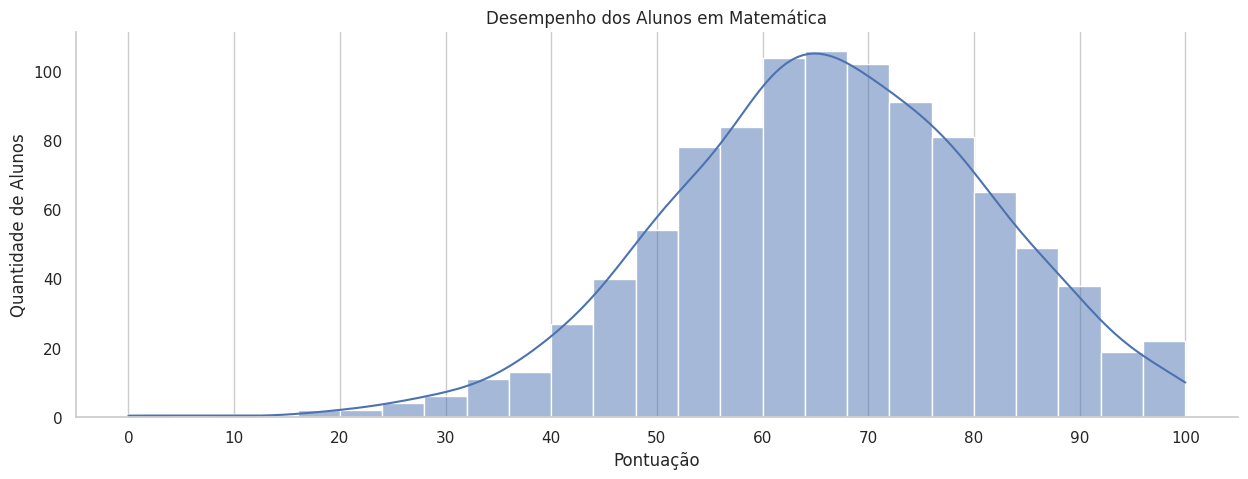

In [2]:
''' Escreva sua justificativa e análise aqui:
1) As Notas dos Alunos estão mais concentradas entre 50 e 80 Pontos.
Possui uma forma assimetrica à esquerda;
O centro a ser utilizado seria a Mediana;
E a dispersão está focada entre o 1° e 3° Quartil(IQR).

2) O Gráfico mais recomendado é o Histograma,
visto que possui apenas uma variavel Quantitativa, além disso,
auxilia na interpretação dos dados por "Area", ou seja,
qual a area de notas é mais densa(que nesse caso é de 50 a 80).

4) Sim, há evidências de assimetria, principalmente por possuir muitos valores
concentrados mais a direita do gráfico. A Nota mais comum esta entre 60 e 70
Aproximadamente 65
'''
#3)
# Seu código Python para o gráfico:
plt.figure(figsize=(15,5))
sns.histplot(data= df_performance, x="math_score", kde=True) #grafico escolhido
plt.title("Desempenho dos Alunos em Matemática")
plt.xlabel("Pontuação")
plt.ylabel("Quantidade de Alunos")
plt.xticks(np.arange(0,101,10))
plt.grid(axis='y')
sns.despine()
plt.show()



**Desafio 1.2: Impacto do Nível de Escolaridade dos Pais nas Notas de Leitura**

Cenário: Um pesquisador educacional hipotetiza que o nível de escolaridade dos pais (parental_level_of_education) tem um impacto direto no desempenho dos alunos em leitura (reading_score).

Sua Tarefa:

1. Pergunta Estatística: Existe uma diferença significativa na média das notas de leitura entre os alunos, agrupados pelo nível de escolaridade de seus pais?

2. Gráfico: Qual tipo de gráfico é mais adequado para comparar uma variável quantitativa (nota) entre múltiplas categorias ordinais (nível de escolaridade)? Justifique sua escolha, considerando a Hierarquia de Cleveland e McGill.

3. Implementação: Crie o gráfico em Python. Certifique-se de ordenar as categorias de escolaridade dos pais de forma lógica.

4. Análise: O que o gráfico revela sobre a hipótese? Há uma tendência clara? Quais são as médias de leitura para cada grupo?



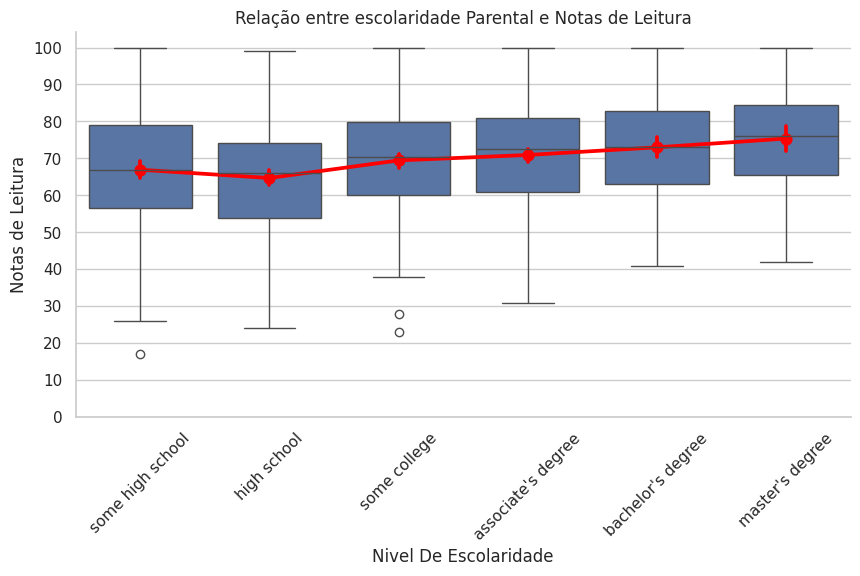

In [3]:
''' Escreva sua justificativa e análise aqui:
1) Existe uma diferença, porém não é muito significativa
uma vez que as medias possuem valores consideravelmente próximos

2) BoxPlot é o gráfico mais viável para essa situação, uma vez que o mesmo
permite a visualização da mediana das notas de cada grupo, o IQR(Intervalo entre o 1° e 3° Quartil)
além de permitir a percepção de valores dispersos(Ex: Outliers). Também Segue o
Príncipio de "posição em uma escala comum" de Cleaveland e McGill

4) De acordo com o Gráfico, a hipotese se mostra insustentavel, uma vez que,
as notas não divergem muito entre si, além disso, na ordem de escolaridade
feita, é possivel notar que alunos que possuem pais com nivel de escolaridade:
"High school"(2º nivel mais baixo) tiveram um desempenho médio abaixo do que os
alunos com pais "Some high school"(Nivel mais baixo de escolaridade), logo, para
que essa hipotese houvesse sustento, deveria haver uma diferença de media/mediana
das notas muito elevada entre o nivel mais baixo e o mais alto, oque não é percebido
no grafico.
'''
#3
escolarity_sequence = [
    'some high school',
    'high school',
    'some college',
    "associate's degree",
    "bachelor's degree",
    "master's degree"
]
# Seu código Python para o gráfico:
plt.figure(figsize=(10, 5))
sns.boxplot(x='parental_level_of_education',
            y='reading_score',
            data=df_performance,
            order=escolarity_sequence)
sns.pointplot(x='parental_level_of_education',
              y='reading_score',
              data=df_performance,
              order=escolarity_sequence,
              color='red')  # média
plt.xticks(rotation=45)
plt.yticks(np.arange(0, 101,10))
plt.title("Relação entre escolaridade Parental e Notas de Leitura")
plt.xlabel("Nivel De Escolaridade")
plt.ylabel("Notas de Leitura")

plt.show()

**Desafio 1.3: Relação entre Notas de Leitura e Escrita**

Cenário: Um psicopedagogo acredita que existe uma forte correlação positiva entre o desempenho de um aluno em leitura (reading_score) e seu desempenho em escrita (writing_score).

Sua Tarefa:

1. Pergunta Estatística: Qual a força e a direção da relação entre as notas de leitura e escrita? Há evidências de uma correlação linear?

2. Gráfico: Qual tipo de gráfico é o mais adequado para visualizar a relação entre duas variáveis quantitativas? Justifique sua escolha, focando na precisão perceptiva.

3. Implementação: Crie o gráfico em Python.

4. Análise: O gráfico suporta a hipótese de correlação positiva? Há algum outlier ou padrão interessante?



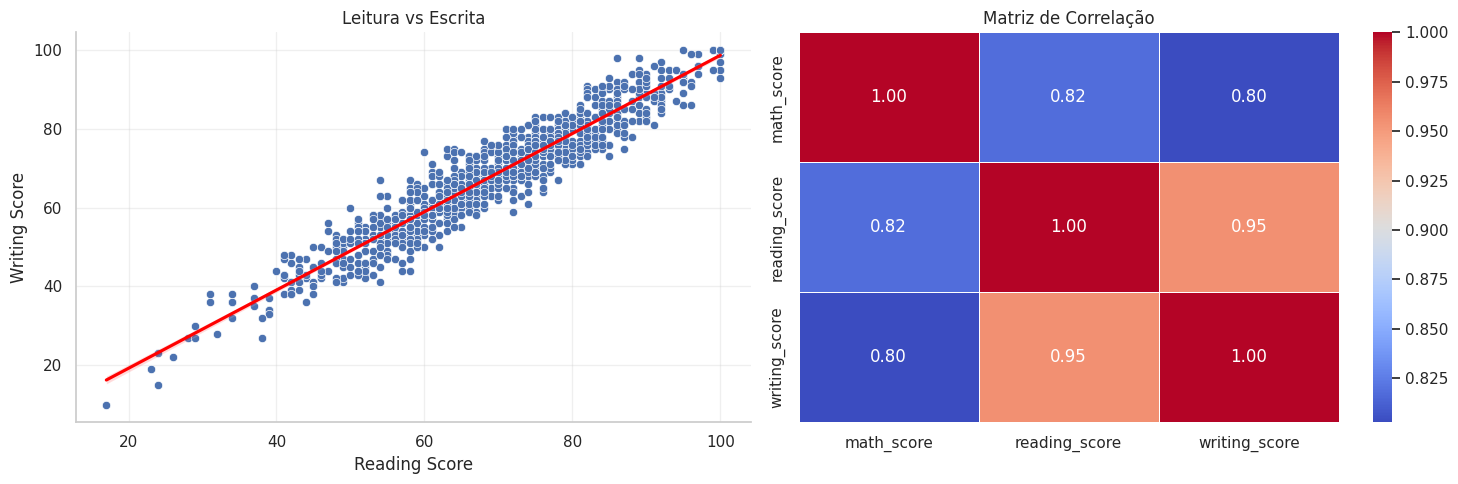

In [4]:
from numpy._core import numeric
''' Escreva sua justificativa e análise aqui:
1) A relação entre as notas possui uma força positiva e uma  forte relação (0.95).
Sim, há evidências de que existe uma correlação linear, visto que,
a linha de regressão "segue" os dados, o valor de correlação no HeatMap é alta, além disso
o dados do scatterplot tendem a criar uma ascendência.

2)O Gráfico mais adequado para esse caso seria o scatter plot,uma vez que:
Evidencia a correlação positiva ou negativa (positiva no caso em questão);
Representa cada aluno como um 'ponto';
Possibilita a percepção de uma tendência;
E auxilia na visualização de outliers.
Juntamente a ele, um HeatMap, para que haja valores quantitativos mais precisos
quanto a correlação entre os dados (reading_score e writng_score)

4)O gráfico não apresenta outliers significativos,
pois os dados estão bem distribuídos ao redor da linha de regressão,
indicando um padrão consistente sem valores extremamente discrepantes.
'''
#3)
# Seu código Python para o gráfico:
fig, axs = plt.subplots(1, 2, figsize=(15, 5))

# Correlação (apenas numéricos)
correlacao = df_performance.corr(numeric_only=True)

# Scatter plot + regplot
sns.scatterplot(
    data=df_performance,
    x='reading_score',
    y='writing_score',
    ax=axs[0]
)
sns.regplot(
    data=df_performance,
    x='reading_score',
    y='writing_score',
    scatter=False,  # só a linha
    ax=axs[0],
    color='red'
)
axs[0].grid(alpha=0.3)
axs[0].set_title("Leitura vs Escrita")
axs[0].set_xlabel("Reading Score")
axs[0].set_ylabel("Writing Score")

# Heatmap
sns.heatmap(
    correlacao,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5,
    ax=axs[1]
)

axs[1].set_title("Matriz de Correlação")

plt.tight_layout()
plt.show()



**Desafio 1.4: Proporção de Gêneros e Preparação para o Teste**

Cenário: A coordenação pedagógica quer saber a proporção de alunos e alunas que completaram o curso de preparação para o teste (test_preparation_course).

Sua Tarefa:

1. Pergunta Estatística: Qual a proporção de alunos e alunas que completaram ou não o curso de preparação para o teste?

2. Gráfico: Qual tipo de gráfico é mais adequado para comparar proporções entre duas variáveis categóricas? Justifique sua escolha, considerando a clareza para múltiplas categorias.

3. Implementação: Crie o gráfico em Python.

4. Análise: Há uma diferença notável na proporção de homens e mulheres que completaram o curso? Qual grupo tem maior participação?



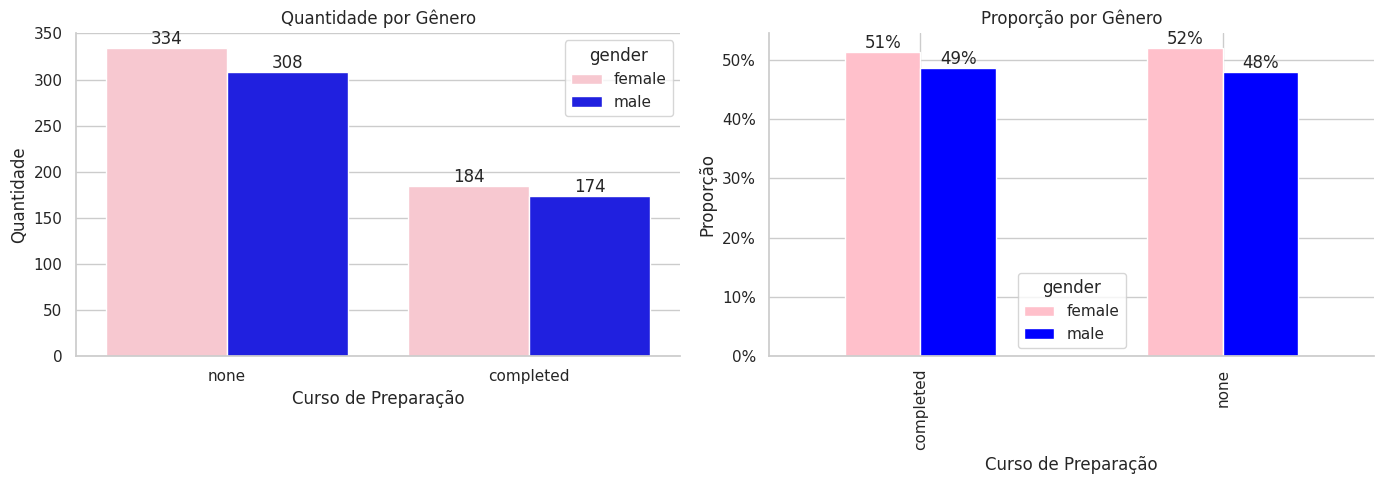

In [5]:
''' Escreva sua justificativa e análise aqui:
1) A proporção é quase 50/50, mas sendo mais exato fica:
Completaram -- Mulheres: 52%; Homens: 48%
Não Completaram -- Mulheres:51%; Homens: 49%¨

2) O gráfico mais adequado para essa questão é o gráfico de Barras, pois
ele permite comparar duas variáveis categóricas ao mesmo tempo de forma clara e precisa.

4)Não há uma diferença notavel, visto que não chega a ter uma disparidade maior que 5%.
O grupo com maior Participação é o feminino
'''
#3
# Seu código Python para o gráfico:
from matplotlib.ticker import PercentFormatter

fig, axs = plt.subplots(ncols=2, figsize=(14,5))

# Grafico de barras:
ax1 = sns.countplot(
    data=df_performance,
    x='test_preparation_course',
    hue='gender',
    palette={'female': 'pink', 'male': 'blue'},
    ax=axs[0]
)

axs[0].set_title("Quantidade por Gênero")
axs[0].set_xlabel("Curso de Preparação")
axs[0].set_ylabel("Quantidade")

# valores nas barras
for p in ax1.patches:
    height = p.get_height()
    if height > 0:
        ax1.annotate(
            f'{int(height)}',
            (p.get_x() + p.get_width()/2., height),
            ha='center',
            va='bottom'
        )

# Grafico de Proporção
proporcao = pd.crosstab(
    df_performance['test_preparation_course'],
    df_performance['gender'],
    normalize='index'
)

proporcao.plot(
    kind='bar',
    ax=axs[1],
    color=['pink', 'blue']
)

axs[1].set_title("Proporção por Gênero")
axs[1].set_xlabel("Curso de Preparação")
axs[1].set_ylabel("Proporção")

# 🔥 formatar eixo Y como porcentagem
axs[1].yaxis.set_major_formatter(PercentFormatter(1))

# valores nas barras (%)
for p in axs[1].patches:
    height = p.get_height()
    if height > 0:
        axs[1].annotate(
            f'{height*100:.0f}%',
            (p.get_x() + p.get_width()/2., height),
            ha='center',
            va='bottom'
        )

plt.tight_layout()
plt.show()

**Desafio 1.5: Comparação de Notas Médias por Raça/Etnia em Todas as Matérias**

Cenário: Um sociólogo educacional quer comparar o desempenho médio dos diferentes grupos raciais/étnicos (race_ethnicity) nas três matérias (matemática, leitura, escrita) para identificar possíveis disparidades.

Sua Tarefa:

1. Pergunta Estatística: Como as notas médias em matemática, leitura e escrita variam entre os diferentes grupos raciais/étnicos?

2. Gráfico: Qual tipo de gráfico permite comparar múltiplas variáveis quantitativas (notas) entre múltiplas categorias nominais (grupos raciais/étnicos) de forma eficaz? Justifique sua escolha, pensando na clareza da comparação.

3. Implementação: Crie o gráfico em Python. Pode ser necessário reestruturar os dados (usar melt do pandas).

4. Análise: Quais grupos raciais/étnicos se destacam em quais matérias? Há padrões consistentes de desempenho?

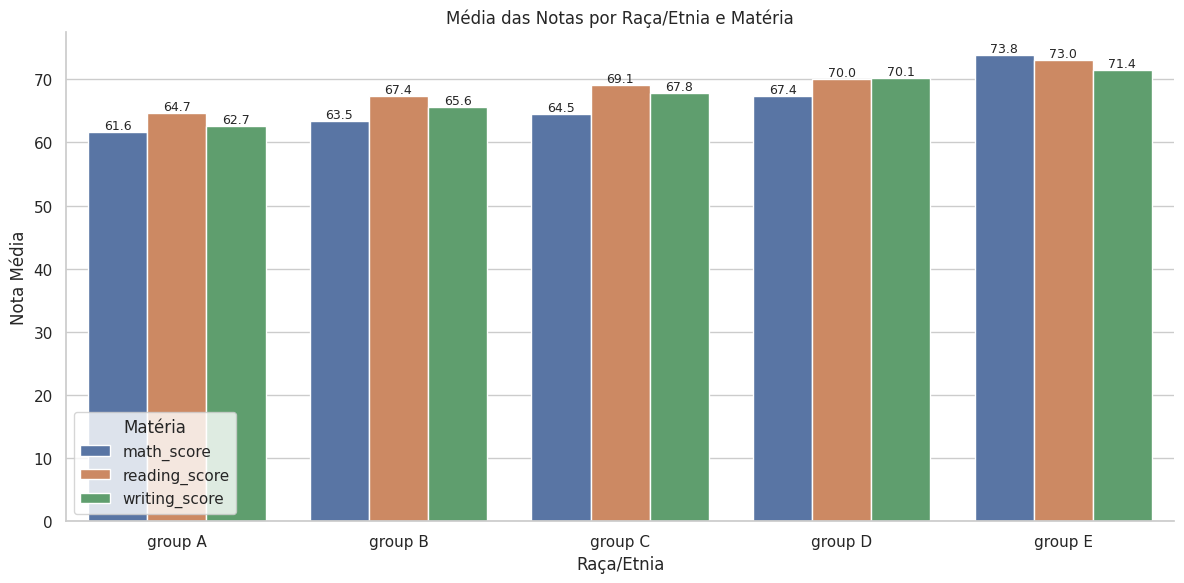

In [21]:
''' Escreva sua justificativa e análise aqui:
1)As notas médias variam de forma consistente entre os grupos raciais/étnicos.
Alguns grupos apresentam médias mais altas em todas as disciplinas,
enquanto outros mantêm médias mais baixas de forma geral.

2)O gráfico de barras agrupadas é o mais adequado,
pois permite comparar múltiplas variáveis quantitativas entre diferentes categorias nominais
de forma clara e precisa, utilizando a altura das barras para facilitar a interpretação e
a comparação direta entre grupos e disciplinas.

4)Math_score = Grupo: E
Reading_score = Grupos:Todos possuem médias elevadas em seus grupos
Writing_score = Grupos: D e E
'''
#3
# Seu código Python para o gráfico:

df_melt = df_performance.melt(
    id_vars='race_ethnicity',
    value_vars=['math_score', 'reading_score', 'writing_score'],
    var_name='subject',
    value_name='score'
)

# Ordem alfabética
ordem = sorted(df_melt['race_ethnicity'].unique())

plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=df_melt,
    x='race_ethnicity',
    y='score',
    hue='subject',
    estimator='mean',
    order=ordem,
    errorbar=None
)

plt.title("Média das Notas por Raça/Etnia e Matéria")
plt.xlabel("Raça/Etnia")
plt.ylabel("Nota Média")
plt.legend(title="Matéria")

# Adicionar valores nas barras
for p in ax.patches:
    height = p.get_height()

    if height > 0:
        ax.annotate(
            f'{height:.1f}',
            (p.get_x() + p.get_width()/2., height),
            ha='center',
            va='bottom',
            fontsize=9
        )

plt.tight_layout()
plt.show()

### Parte 2: Desafios de Refatoração Estatística e Visual

Para cada cenário abaixo, você receberá um código Python que gera um gráfico com problemas de design. Sua tarefa é:

1. Analisar o gráfico gerado e identificar pelo menos 3 problemas com base nos princípios de Tufte (Data-Ink Ratio, Lie Factor, Chartjunk), Gestalt (Proximidade, Semelhança, Fechamento, etc.) e/ou Cleveland-McGill (eficácia da codificação).

2. Descrever os problemas identificados.

3. Modificar o código para refatorar o gráfico, aplicando os princípios para torná-lo mais honesto, eficiente e visualmente claro.



Desafio 2.1:  Comparação de Notas Médias de Matemática por Gênero

Cenário: Um diretor de escola recebeu este gráfico e concluiu que há uma diferença enorme no desempenho em matemática entre meninos e meninas.

Sua Tarefa:

1. Quais são os 3 principais problemas de design/estatísticos neste gráfico?

2. Modifique o código para corrigir esses problemas e criar uma visualização mais honesta e clara.

/tmp/ipykernel_4371/2082650646.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x="gender", y="math_score", data=df_gender_math, palette=["skyblue", "lightcoral"])


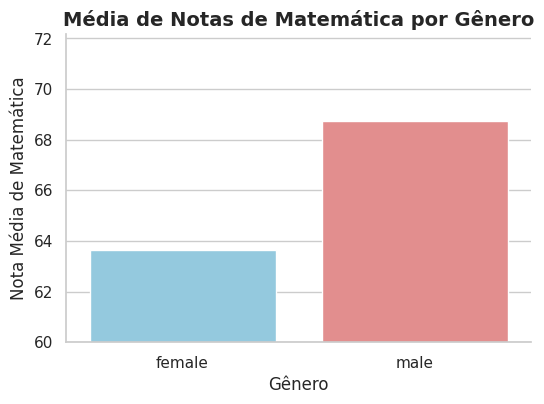

In [7]:
# Dados para o Desafio 2.1
df_gender_math = df_performance.groupby("gender")["math_score"].mean().reset_index()

plt.figure(figsize=(6, 4))
ax = sns.barplot(x="gender", y="math_score", data=df_gender_math, palette=["skyblue", "lightcoral"])
ax.set_ylim(bottom=60) # Eixo Y começando alto
ax.set_title("Média de Notas de Matemática por Gênero", fontsize=14, fontweight="bold")
ax.set_xlabel("Gênero")
ax.set_ylabel("Nota Média de Matemática")
plt.show()

/tmp/ipykernel_4371/2357024955.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


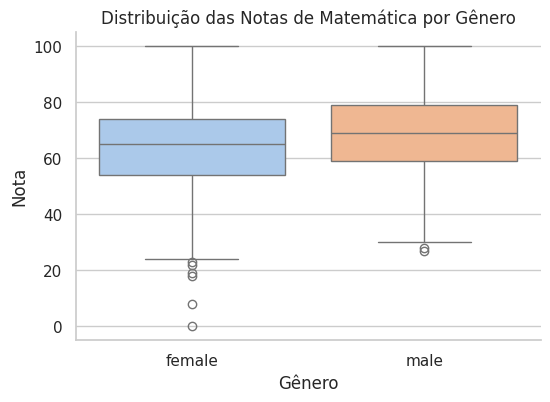

In [22]:
# 1. Problemas identificados:
#    a) Eixo Y truncado (começando em 60), o que distorce a percepção da diferença entre os grupos (Lie Factor - Tufte)
#    b) Uso de gráfico de barras apenas com média, escondendo a variabilidade dos dados (Cleveland-McGill)
#    c) Excesso de destaque visual (cores fortes e título em negrito), gerando chartjunk e desviando o foco dos dados

# 2. Seu código Python refatorado:
plt.figure(figsize=(6, 4))

sns.boxplot(
    data=df_performance,
    x="gender",
    y="math_score",
    palette="pastel"
)

plt.title("Distribuição das Notas de Matemática por Gênero")
plt.xlabel("Gênero")
plt.ylabel("Nota")

plt.show()

**Desafio 2.2: Impacto do Almoço na Nota de Escrita (Chartjunk e Cores Ineficazes)**

Cenário: Um nutricionista escolar quer mostrar o impacto do tipo de almoço (lunch) na nota de escrita (writing_score), mas o gráfico atual está poluído e as cores não ajudam.

Sua Tarefa:

1. Quais são os 3 principais problemas de design neste gráfico, focando no Data-Ink Ratio e no uso de cores?

2. Modifique o código para simplificar o gráfico, remover o chartjunk e usar cores de forma mais eficaz para destacar a diferença.

/tmp/ipykernel_4371/2306030820.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x="lunch", y="writing_score", data=df_performance, palette=["green", "purple"])


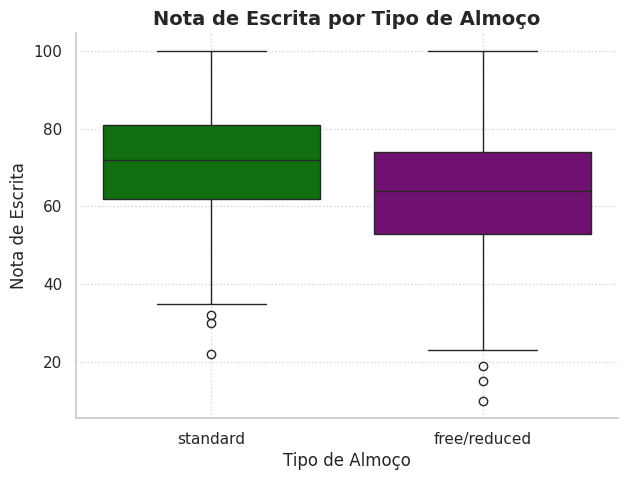

In [9]:
# Dados para o Desafio 2.2
plt.figure(figsize=(7, 5))
ax = sns.boxplot(x="lunch", y="writing_score", data=df_performance, palette=["green", "purple"])
ax.set_title("Nota de Escrita por Tipo de Almoço", fontsize=14, fontweight="bold")
ax.set_xlabel("Tipo de Almoço")
ax.set_ylabel("Nota de Escrita")
ax.grid(True, linestyle=":", alpha=0.8) # Grade pesada
plt.show()

/tmp/ipykernel_4371/1719403708.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


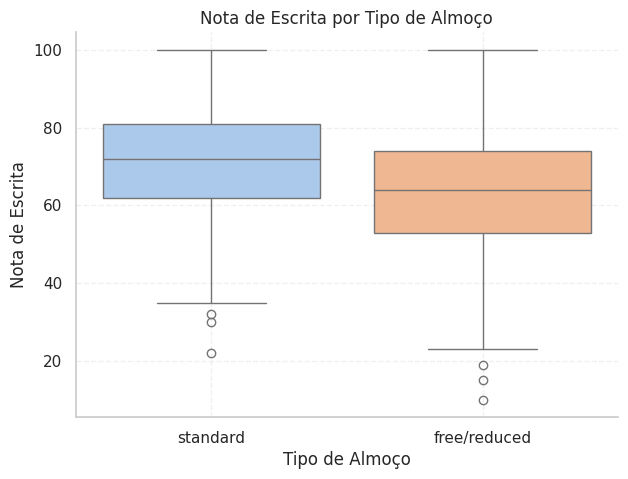

In [23]:
# 1. Problemas identificados:
#    a) Cores pouco intuitivas e sem significado (verde/roxo), prejudicando a interpretação (Gestalt - Semelhança)
#    b) Grade muito forte (alpha alto e linha pontilhada), gerando poluição visual (Chartjunk - Tufte)
#    c) Título com excesso de destaque (negrito forte e grande), competindo com os dados (Data-Ink Ratio)

# 2. Seu código Python refatorado:
plt.figure(figsize=(7, 5))

ax = sns.boxplot(
    data=df_performance,
    x="lunch",
    y="writing_score",
    palette="pastel"  # cores mais suaves
)

# Título mais limpo
ax.set_title("Nota de Escrita por Tipo de Almoço")

ax.set_xlabel("Tipo de Almoço")
ax.set_ylabel("Nota de Escrita")

# Grade mais leve
ax.grid(True, linestyle="--", alpha=0.3)

sns.despine()

plt.show()

**Desafio 2.3: Distribuição de Notas de Leitura por Raça/Etnia (Sobrecarga Visual)**

Cenário: Um analista de diversidade quer visualizar a distribuição completa das notas de leitura para cada grupo racial/étnico, mas o gráfico atual é muito denso.

Sua Tarefa:

1. Quais são os 3 principais problemas de design neste gráfico, especialmente em relação à sobrecarga visual e à clareza da comparação entre grupos?

2. Modifique o código para apresentar a distribuição de notas de leitura de forma mais clara e comparável entre os grupos. Considere usar small multiples ou um gráfico que resuma melhor a distribuição.


/tmp/ipykernel_4371/3061236733.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="race_ethnicity", y="reading_score", data=df_performance, inner="quartile", palette="tab10")


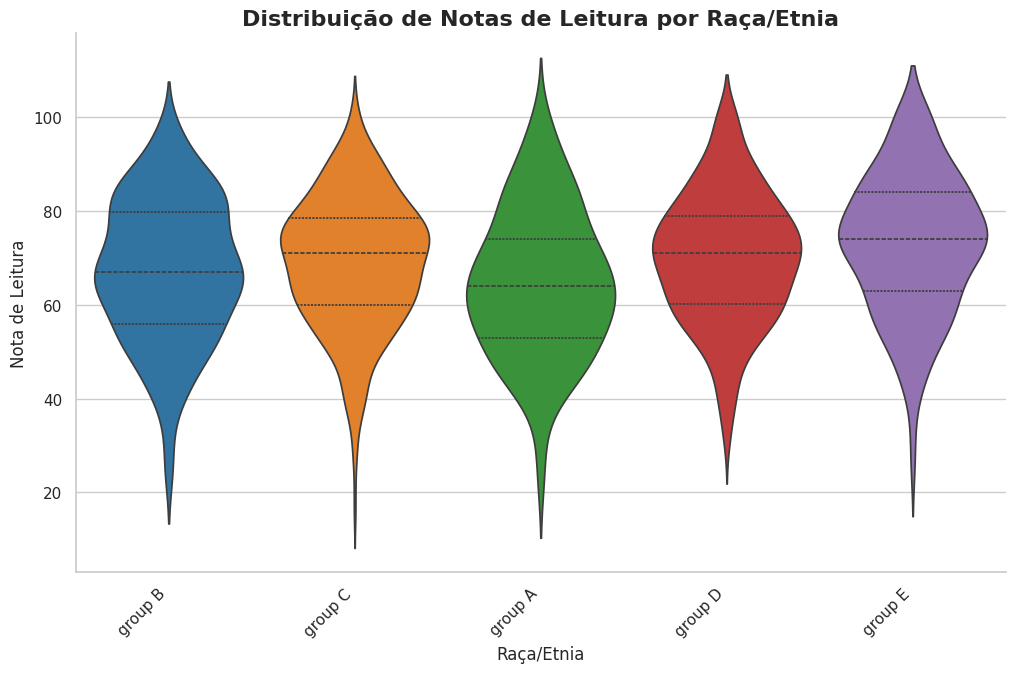

In [11]:
# Dados para o Desafio 2.3
plt.figure(figsize=(12, 7))
sns.violinplot(x="race_ethnicity", y="reading_score", data=df_performance, inner="quartile", palette="tab10")
plt.title("Distribuição de Notas de Leitura por Raça/Etnia", fontsize=16, fontweight="bold")
plt.xlabel("Raça/Etnia")
plt.ylabel("Nota de Leitura")
plt.xticks(rotation=45, ha='right')
plt.show()

/tmp/ipykernel_4371/1438730859.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


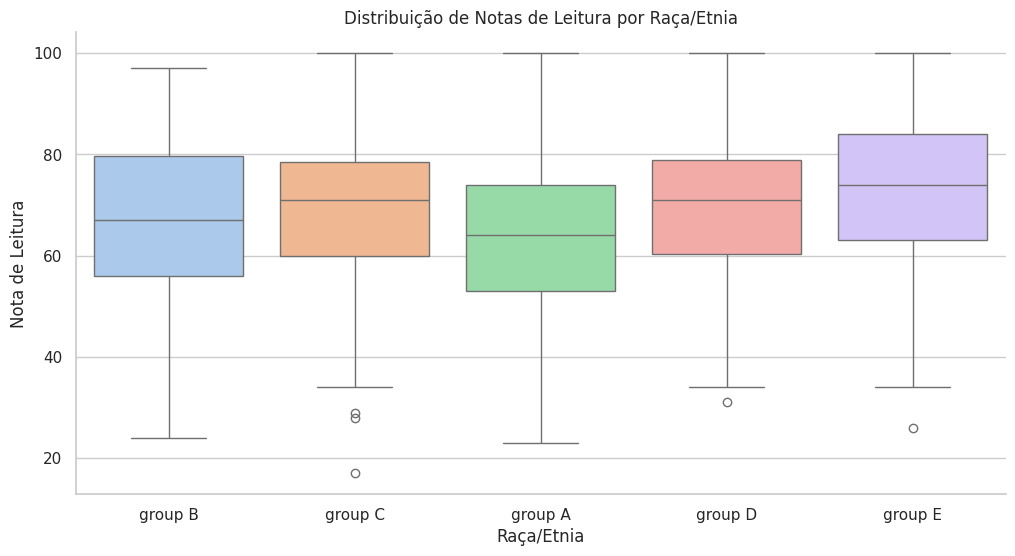

In [24]:
# 1. Problemas identificados:
#    a) Excesso de informação no violinplot (densidade + quartis), deixando o gráfico visualmente denso (Chartjunk / baixa clareza)
#    b) Uso de muitas cores distintas (palette="tab10"), dificultando a comparação entre grupos (Gestalt - Semelhança)
#    c) Título muito destacado e rótulos inclinados excessivamente, prejudicando a leitura (Data-Ink Ratio)

# 2. Seu código Python refatorado:
plt.figure(figsize=(12, 6))

ax = sns.boxplot(
    data=df_performance,
    x="race_ethnicity",
    y="reading_score",
    palette="pastel"
)

# Título mais limpo
plt.title("Distribuição de Notas de Leitura por Raça/Etnia")

plt.xlabel("Raça/Etnia")
plt.ylabel("Nota de Leitura")

# Rotação mais leve
plt.xticks(rotation=0)

# Remover elementos desnecessários
sns.despine()

plt.show()

Desafio 2.4: Correlação entre Notas de Matemática e Leitura (Pontos Sobrepostos)

Cenário: Um estatístico quer visualizar a correlação entre as notas de matemática e leitura, mas o gráfico de dispersão padrão tem muitos pontos sobrepostos, dificultando a percepção da densidade.

Sua Tarefa:

1. Quais são os 3 principais problemas de design neste gráfico, especialmente em relação à sobreposição de pontos e à percepção da densidade?

2. Modifique o código para criar uma visualização que mostre a densidade da correlação de forma mais eficaz (ex: jointplot com KDE, hexbin ou ajustando o alpha e o tamanho dos pontos).

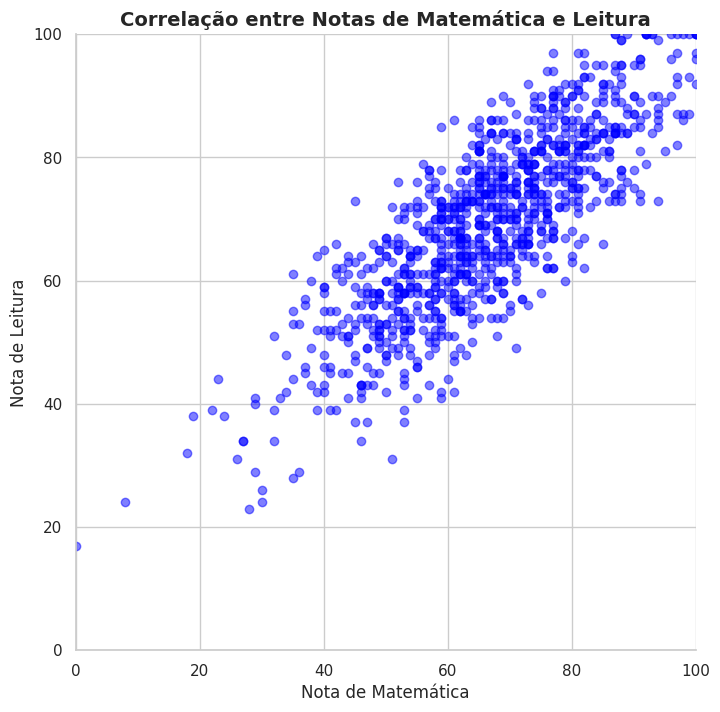

In [13]:
# Dados para o Desafio 2.4
plt.figure(figsize=(8, 8))
plt.scatter(x=df_performance["math_score"], y=df_performance["reading_score"], alpha=0.5, color="blue")
plt.title("Correlação entre Notas de Matemática e Leitura", fontsize=14, fontweight="bold")
plt.xlabel("Nota de Matemática")
plt.ylabel("Nota de Leitura")
plt.xlim(0, 100)
plt.ylim(0, 100)
plt.show()

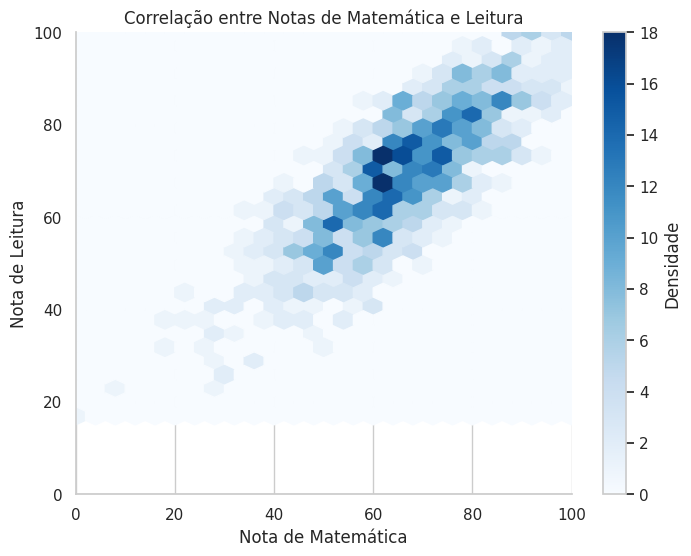

In [25]:
# 1. Problemas identificados:
#    a) Sobreposição de pontos (overplotting), dificultando perceber a densidade dos dados (Cleveland-McGill)
#    b) Uso de cor única e pouco informativa, sem ajudar na percepção de concentração (Gestalt - Semelhança)
#    c) Título com excesso de destaque (negrito), competindo com os dados (Data-Ink Ratio)

# 2. Seu código Python refatorado:
plt.figure(figsize=(8, 6))

# 🔹 Usando hexbin para mostrar densidade
plt.hexbin(
    x=df_performance["math_score"],
    y=df_performance["reading_score"],
    gridsize=25,
    cmap="Blues"
)

plt.colorbar(label="Densidade")

plt.title("Correlação entre Notas de Matemática e Leitura")
plt.xlabel("Nota de Matemática")
plt.ylabel("Nota de Leitura")

plt.xlim(0, 100)
plt.ylim(0, 100)

plt.show()

Desafio 2.5: Desempenho Geral por Curso de Preparação (Gráfico de Pizza com Múltiplas Variáveis)

Cenário: Um conselheiro estudantil quer visualizar o impacto do curso de preparação (test_preparation_course) no desempenho geral dos alunos, mas o gráfico atual tenta mostrar muitas coisas de uma vez de forma ineficaz.

Sua Tarefa:

1. Quais são os 3 principais problemas de design/estatísticos neste gráfico, especialmente em relação ao uso do gráfico de pizza para comparar médias e à representação de múltiplas variáveis?

2. Modifique o código para criar uma visualização mais eficaz que compare o desempenho médio em cada matéria (não apenas a média geral) entre os alunos que completaram e os que não completaram o curso de preparação.

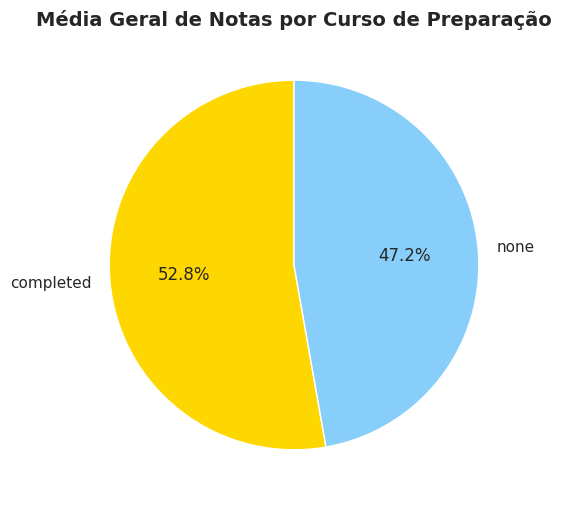

In [15]:
# Dados para o Desafio 2.5
df_prep_course = df_performance.groupby("test_preparation_course")[["math_score", "reading_score", "writing_score"]].mean().mean(axis=1).reset_index(name="overall_average_score")

plt.figure(figsize=(6, 6))
plt.pie(df_prep_course["overall_average_score"], labels=df_prep_course["test_preparation_course"], autopct="%1.1f%%", startangle=90, colors=["gold", "lightskyblue"])
plt.title("Média Geral de Notas por Curso de Preparação", fontsize=14, fontweight="bold")
plt.show()

/tmp/ipykernel_4371/1027358018.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


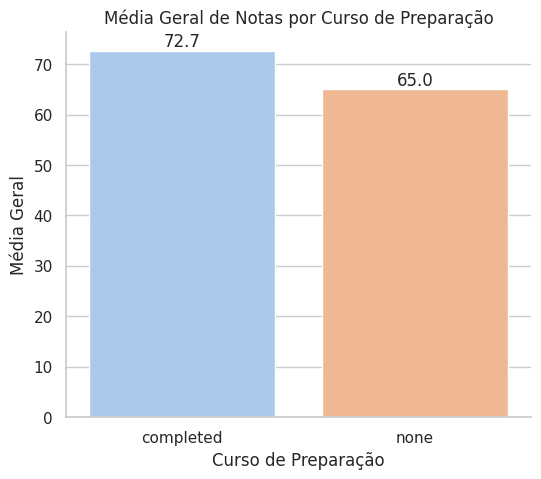

In [26]:
# 1. Problemas identificados:
#    a) Uso de gráfico de pizza para comparar médias, o que dificulta a comparação precisa (Cleveland-McGill - ângulos são menos precisos que comprimentos)
#    b) Pizza sugere proporção de partes de um todo, mas aqui são médias independentes (Lie Factor / interpretação enganosa)
#    c) Pouca capacidade de comparação visual clara entre categorias (baixa precisão perceptiva)

# 2. Seu código Python refatorado:
plt.figure(figsize=(6, 5))

ax = sns.barplot(
    data=df_prep_course,
    x="test_preparation_course",
    y="overall_average_score",
    palette="pastel"
)

plt.title("Média Geral de Notas por Curso de Preparação")
plt.xlabel("Curso de Preparação")
plt.ylabel("Média Geral")

# 🔹 Adicionar valores nas barras
for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f'{height:.1f}',
        (p.get_x() + p.get_width()/2., height),
        ha='center',
        va='bottom'
    )

sns.despine()

plt.show()